In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [2]:
df = pd.read_csv("EarthquakeBigDataAnalysis (1).csv")
df.head()

,time,latitude,longitude,depth,mag,place,type,year,month,hour,lat_long_interaction,depth_squared,log_depth
0,2025-03-03 15:40:36.720000+00:00,12.6846,146.2399,10.000,5.1,"174 km ESE of Yigo Village, Guam",earthquake,2025,3,15,1854.994636,100.000000,2.397895
1,2025-03-03 10:25:28.644000+00:00,-16.7565,-177.3640,413.683,5.4,"282 km SSE of Alo, Wallis and Futuna",earthquake,2025,3,10,2971.999866,171133.624489,6.027514
2,2025-03-03 06:25:34.143000+00:00,27.3373,61.0748,32.943,5.2,"41 km ENE of Iranshahr, Iran",earthquake,2025,3,6,1669.620130,1085.241249,3.524683
3,2025-03-02 18:42:09.427000+00:00,-3.5151,129.4579,28.891,5.2,"59 km ESE of Masohi, Indonesia",earthquake,2025,3,18,-455.057464,834.689881,3.397557
4,2025-03-02 14:16:58.339000+00:00,-10.2343,66.0620,10.000,5.3,Mid-Indian Ridge,earthquake,2025,3,14,-676.098327,100.000000,2.397895


In [3]:
#Create Target Variable
df["impact"] = df["mag"].apply(lambda x: "High Impact" if x >= 6 else "Low Impact")

In [4]:
df["impact"].value_counts()

,count
impact,
Low Impact,15686
High Impact,1328


In [5]:
#Text Preprocessing
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_place"] = df["place"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
#Convert Text to Numbers
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_place"])
y = df["impact"]

In [7]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)

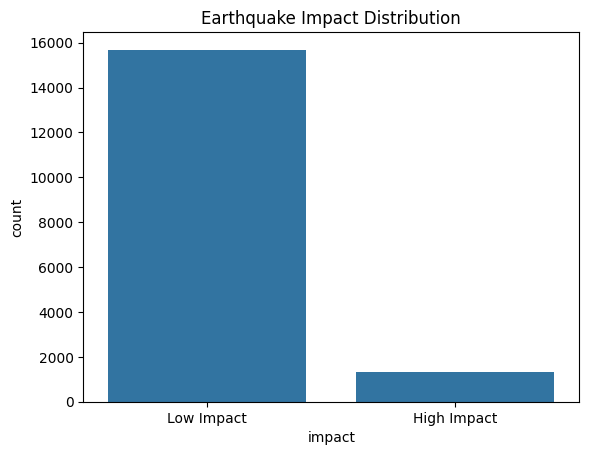

In [11]:
sns.countplot(x="impact", data=df)

plt.title("Earthquake Impact Distribution")
plt.show()

In [12]:
# One example
sample = ["10 km south of Alaska"]

sample_clean = [clean_text(sample[0])]

sample_vector = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Predicted Impact:", prediction[0])

Predicted Impact: Low Impact


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9180135174845724


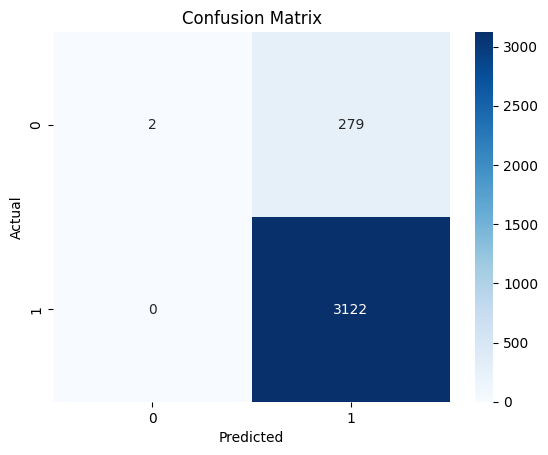

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()